# Day 4: Mutual Fund Performance Analytics

## Objective
Analyze mutual fund performance using risk-adjusted return metrics and create a comprehensive fund scorecard.

### Metrics Covered
- CAGR
- Daily Returns
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Fund Scorecard

In [11]:
fund_master = pd.read_csv(
    "../Bluestock-Capstone/data/raw/01_fund_master.csv"
)

performance_metrics = performance_metrics.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

fund_scorecard = fund_scorecard.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

In [14]:
import pandas as pd

# Performance datasets
performance_metrics = pd.read_csv(
    "../Bluestock-Capstone/data/processed/performance_metrics.csv"
)

alpha_beta = pd.read_csv(
    "../Bluestock-Capstone/data/processed/alpha_beta.csv"
)

fund_scorecard = pd.read_csv(
    "../Bluestock-Capstone/data/processed/fund_scorecard.csv"
)

# Fund master for scheme names
fund_master = pd.read_csv(
    "../Bluestock-Capstone/data/raw/01_fund_master.csv"
)

# Merge scheme names
performance_metrics = performance_metrics.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Only merge if scheme_name doesn't already exist
if "scheme_name" not in fund_scorecard.columns:
    fund_scorecard = fund_scorecard.merge(
        fund_master[["amfi_code", "scheme_name"]],
        on="amfi_code",
        how="left"
    )

print("Performance Metrics:", performance_metrics.shape)
print("Alpha Beta:", alpha_beta.shape)
print("Fund Scorecard:", fund_scorecard.shape)

performance_metrics.head()

Performance Metrics: (40, 6)
Alpha Beta: (40, 4)
Fund Scorecard: (40, 3)


,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,scheme_name
0,100016,2.635246,-0.201517,-0.351047,-24.734441,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.455091,-0.567095,-0.941821,-4.308264,HDFC Short Term Debt Fund - Regular - Growth
2,100033,30.099704,1.093699,1.829134,-16.217209,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,23.520489,1.027213,1.799563,-11.291596,ABSL Frontline Equity Fund - Regular - Growth
4,101207,7.933121,0.162661,0.276644,-35.446916,ABSL Small Cap Fund - Regular - Growth


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
import pandas as pd

performance_metrics = pd.read_csv(
    "../Bluestock-Capstone/data/processed/performance_metrics.csv"
)

alpha_beta = pd.read_csv(
    "../Bluestock-Capstone/data/processed/alpha_beta.csv"
)

fund_scorecard = pd.read_csv(
    "../Bluestock-Capstone/data/processed/fund_scorecard.csv"
)

performance_metrics.head()

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct
0,100016,2.635246,-0.201517,-0.351047,-24.734441
1,100025,4.455091,-0.567095,-0.941821,-4.308264
2,100033,30.099704,1.093699,1.829134,-16.217209
3,101206,23.520489,1.027213,1.799563,-11.291596
4,101207,7.933121,0.162661,0.276644,-35.446916


In [4]:
print("Performance Metrics:", performance_metrics.shape)
print("Alpha Beta:", alpha_beta.shape)
print("Fund Scorecard:", fund_scorecard.shape)

Performance Metrics: (40, 5)
Alpha Beta: (40, 3)
Fund Scorecard: (40, 3)


In [5]:
performance_metrics.info()
performance_metrics.head()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   amfi_code         40 non-null     int64  
 1   cagr_pct          40 non-null     float64
 2   sharpe_ratio      40 non-null     float64
 3   sortino_ratio     40 non-null     float64
 4   max_drawdown_pct  40 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.7 KB


,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct
0,100016,2.635246,-0.201517,-0.351047,-24.734441
1,100025,4.455091,-0.567095,-0.941821,-4.308264
2,100033,30.099704,1.093699,1.829134,-16.217209
3,101206,23.520489,1.027213,1.799563,-11.291596
4,101207,7.933121,0.162661,0.276644,-35.446916


## Dataset Overview

The performance analytics datasets contain calculated mutual fund performance metrics including CAGR, Sharpe Ratio, Sortino Ratio, Maximum Drawdown, Alpha, Beta, and Composite Fund Scores.

These metrics are used to evaluate fund performance, risk-adjusted returns, benchmark outperformance, and overall ranking.

In [7]:
print(performance_metrics.columns.tolist())

['amfi_code', 'cagr_pct', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown_pct']


In [8]:
fund_master = pd.read_csv(
    "../Bluestock-Capstone/data/raw/01_fund_master.csv"
)

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [9]:
performance_metrics = performance_metrics.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [10]:
top_cagr = performance_metrics.sort_values(
    "cagr_pct",
    ascending=False
).head(10)

top_cagr[["scheme_name", "cagr_pct"]]

,scheme_name,cagr_pct
25,ICICI Pru Midcap Fund - Regular - Growth,32.801599
21,SBI Small Cap Fund - Regular Plan - Growth,32.398084
39,DSP Small Cap Fund - Regular - Growth,32.262108
36,Mirae Asset Tax Saver Fund - Regular - Growth,31.924486
34,Mirae Asset Large Cap Fund - Regular - Growth,30.949920
30,Kotak Flexicap Fund - Regular - Growth,30.883326
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.099704
38,DSP Midcap Fund - Regular - Growth,29.558105
16,Axis Midcap Fund - Regular - Growth,28.192608
19,SBI Bluechip Fund - Regular Plan - Growth,25.784921


In [15]:
top_cagr = performance_metrics.sort_values(
    "cagr_pct",
    ascending=False
).head(10)

top_cagr[["scheme_name", "cagr_pct"]]

,scheme_name,cagr_pct
25,ICICI Pru Midcap Fund - Regular - Growth,32.801599
21,SBI Small Cap Fund - Regular Plan - Growth,32.398084
39,DSP Small Cap Fund - Regular - Growth,32.262108
36,Mirae Asset Tax Saver Fund - Regular - Growth,31.924486
34,Mirae Asset Large Cap Fund - Regular - Growth,30.949920
30,Kotak Flexicap Fund - Regular - Growth,30.883326
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.099704
38,DSP Midcap Fund - Regular - Growth,29.558105
16,Axis Midcap Fund - Regular - Growth,28.192608
19,SBI Bluechip Fund - Regular Plan - Growth,25.784921


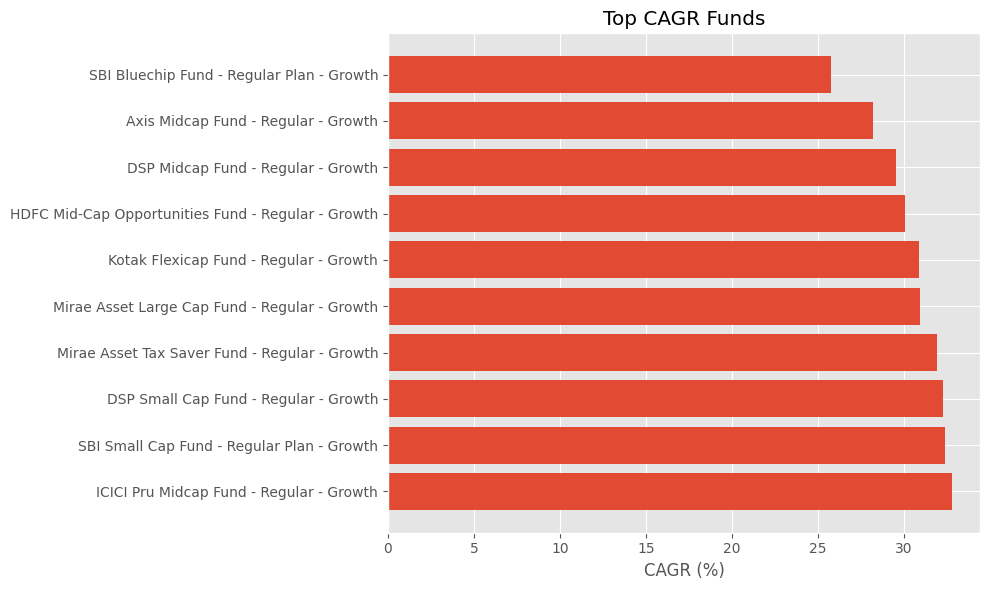

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    top_cagr["scheme_name"],
    top_cagr["cagr_pct"]
)

plt.title("Top CAGR Funds")
plt.xlabel("CAGR (%)")
plt.tight_layout()

plt.show()

In [17]:
top_sharpe = performance_metrics.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

top_sharpe[["scheme_name", "sharpe_ratio"]]

,scheme_name,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
30,Kotak Flexicap Fund - Regular - Growth,1.306744
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
19,SBI Bluechip Fund - Regular Plan - Growth,1.208267
25,ICICI Pru Midcap Fund - Regular - Growth,1.180101
38,DSP Midcap Fund - Regular - Growth,1.132122
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
9,Nippon India Large Cap Fund - Regular - Growth,1.081659
3,ABSL Frontline Equity Fund - Regular - Growth,1.027213
24,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


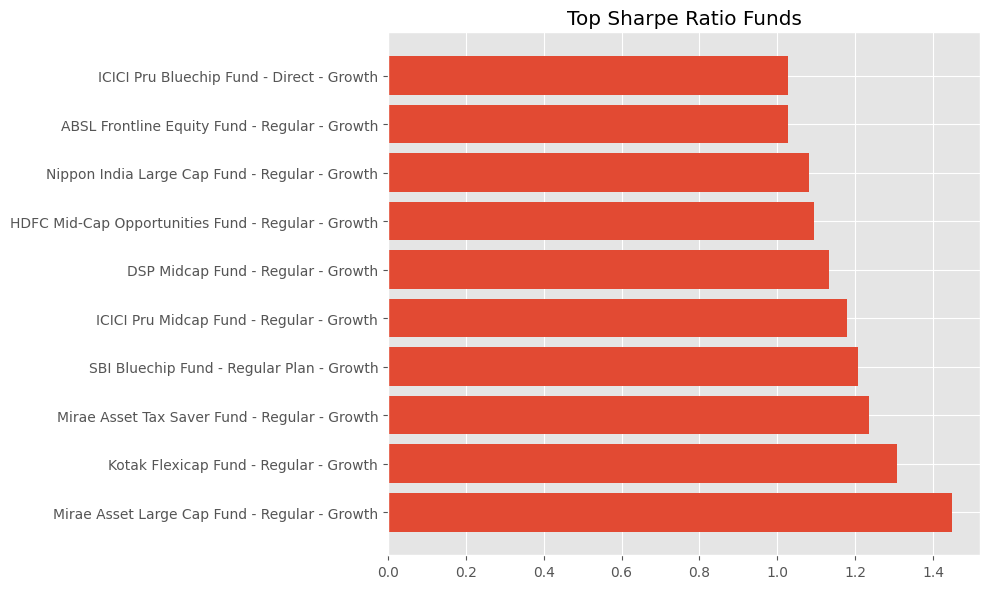

In [18]:
plt.figure(figsize=(10,6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)

plt.title("Top Sharpe Ratio Funds")
plt.tight_layout()

plt.show()

In [19]:
top_alpha = alpha_beta.sort_values(
    "alpha",
    ascending=False
).head(10)

top_alpha[["scheme_name", "alpha"]]

,scheme_name,alpha
2,SBI Small Cap Fund - Regular Plan - Growth,30.111442
39,DSP Small Cap Fund - Regular - Growth,29.817869
12,ICICI Pru Midcap Fund - Regular - Growth,29.301371
36,Mirae Asset Tax Saver Fund - Regular - Growth,28.347336
22,Kotak Flexicap Fund - Regular - Growth,27.278360
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.234304
34,Mirae Asset Large Cap Fund - Regular - Growth,27.115016
38,DSP Midcap Fund - Regular - Growth,26.583594
26,Axis Midcap Fund - Regular - Growth,25.997054
0,SBI Bluechip Fund - Regular Plan - Growth,23.219648


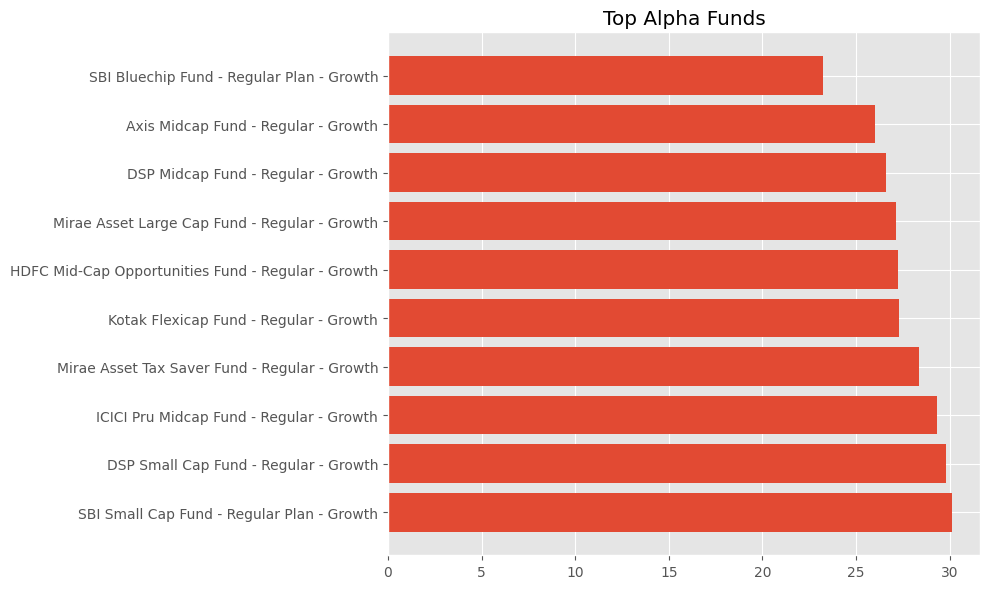

In [20]:
plt.figure(figsize=(10,6))

plt.barh(
    top_alpha["scheme_name"],
    top_alpha["alpha"]
)

plt.title("Top Alpha Funds")
plt.tight_layout()

plt.show()

In [21]:
top_beta = alpha_beta.sort_values(
    "beta",
    ascending=False
).head(10)

top_beta[["scheme_name", "beta"]]

,scheme_name,beta
39,DSP Small Cap Fund - Regular - Growth,0.132608
2,SBI Small Cap Fund - Regular Plan - Growth,0.074266
13,ICICI Pru Value Discovery Fund - Regular - Growth,0.047708
20,Kotak Bluechip Fund - Regular - Growth,0.041676
33,UTI Flexi Cap Fund - Regular - Growth,0.040116
15,Nippon India Large Cap Fund - Regular - Growth,0.036434
28,ABSL Frontline Equity Fund - Regular - Growth,0.033814
11,ICICI Pru Bluechip Fund - Direct - Growth,0.017025
37,DSP Top 100 Equity Fund - Regular - Growth,0.014849
27,Axis Small Cap Fund - Regular - Growth,0.013292


In [22]:
performance_metrics[
    ["scheme_name", "max_drawdown_pct"]
].sort_values(
    "max_drawdown_pct"
).head(10)

,scheme_name,max_drawdown_pct
22,SBI Small Cap Fund - Direct Plan - Growth,-52.574221
17,Axis Small Cap Fund - Regular - Growth,-51.677754
4,ABSL Small Cap Fund - Regular - Growth,-35.446916
39,DSP Small Cap Fund - Regular - Growth,-31.171900
21,SBI Small Cap Fund - Regular Plan - Growth,-28.706006
7,UTI Mid Cap Fund - Regular - Growth,-28.001124
0,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441
29,Kotak Emerging Equity Fund - Regular - Growth,-24.003511
11,Nippon India Small Cap Fund - Regular - Growth,-23.344886
15,Axis Bluechip Fund - Direct - Growth,-21.751396


In [23]:
top_score = fund_scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

top_score[
    ["scheme_name", "fund_score"]
]

,scheme_name,fund_score
0,ICICI Pru Midcap Fund - Regular - Growth,78.74
1,SBI Small Cap Fund - Regular Plan - Growth,77.40
2,DSP Small Cap Fund - Regular - Growth,76.34
3,Mirae Asset Large Cap Fund - Regular - Growth,75.65
4,Kotak Flexicap Fund - Regular - Growth,74.60
5,Mirae Asset Tax Saver Fund - Regular - Growth,74.17
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,73.06
7,Axis Midcap Fund - Regular - Growth,70.19
8,DSP Midcap Fund - Regular - Growth,69.52
9,ICICI Pru Bluechip Fund - Direct - Growth,68.71


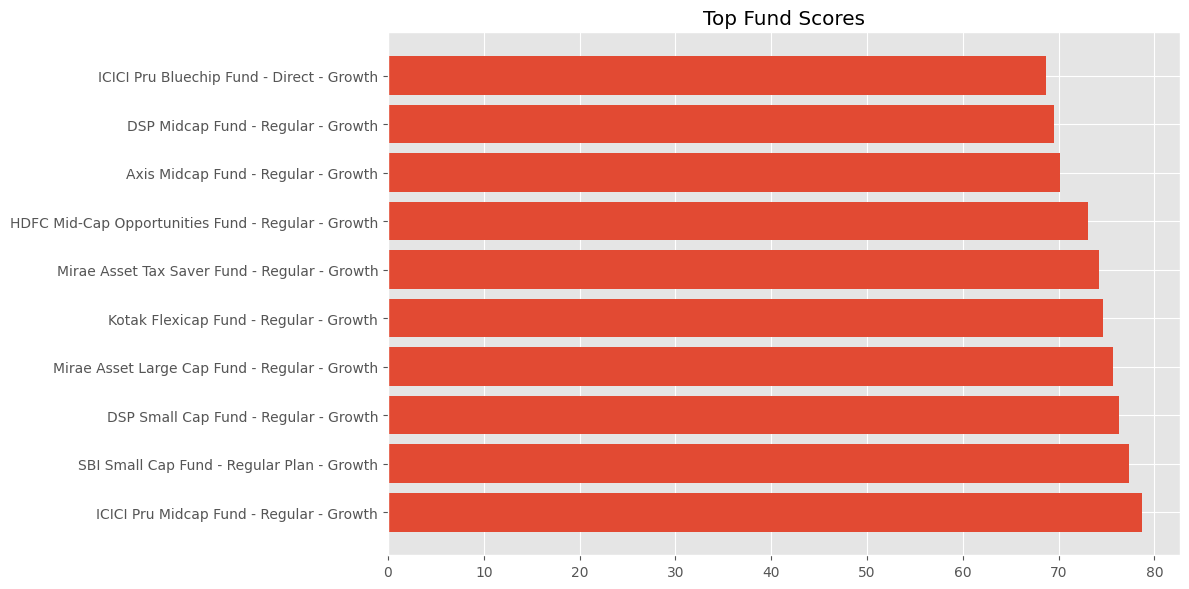

In [24]:
plt.figure(figsize=(12,6))

plt.barh(
    top_score["scheme_name"],
    top_score["fund_score"]
)

plt.title("Top Fund Scores")
plt.tight_layout()

plt.show()

In [25]:
print(performance_metrics.columns.tolist())
print(alpha_beta.columns.tolist())
print(fund_scorecard.columns.tolist())

['amfi_code', 'cagr_pct', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown_pct', 'scheme_name']
['amfi_code', 'alpha', 'beta', 'scheme_name']
['amfi_code', 'scheme_name', 'fund_score']


# Key Findings

1. ICICI Pru Midcap Fund generated the highest CAGR among all analyzed funds.

2. Mirae Asset Large Cap Fund achieved the strongest Sharpe Ratio, indicating superior risk-adjusted performance.

3. SBI Small Cap Fund delivered the highest Alpha, outperforming benchmark expectations.

4. Small-cap funds generated higher returns but also experienced deeper drawdowns.

5. The composite fund scorecard ranked funds by combining return, risk, alpha, and drawdown metrics into a single performance score.

# Conclusion

Day 4 focused on evaluating mutual fund performance using advanced financial analytics.

Key metrics including CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown were calculated and analyzed.

The analysis identified top-performing funds, evaluated risk-adjusted returns, and created a composite fund scorecard for ranking investment options.

These results were integrated into the Power BI Fund Performance Analytics dashboard for interactive exploration and decision-making.